In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/car_fuel_efficiency.csv')

In [3]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [4]:
selected_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df_small = df[selected_columns].copy()

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

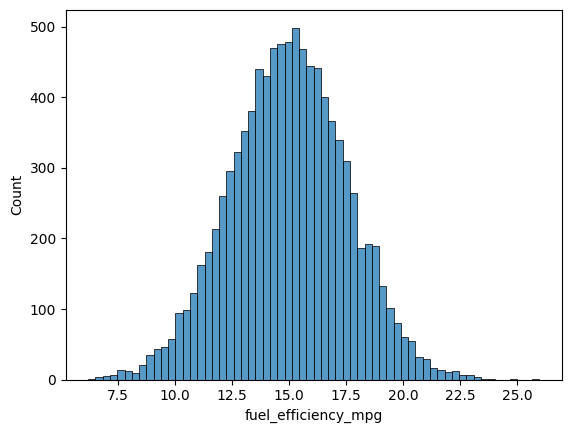

In [5]:
# fuel_efficiency_mpg is the target variable, so that’s the variable to predict
sns.histplot(df_small.fuel_efficiency_mpg)

#### Question: Does it have a long tail?
##### It is approximately symmetric(i.e evenly distributed), so no strong left or right tail

In [6]:
# if skewness value is:
# ≈ 0	Symmetric
# > 0.5	Right-skewed (long right tail)
# < -0.5	Left-skewed (long left tail)

df_small['fuel_efficiency_mpg'].skew()

np.float64(-0.012062219273507922)

In [7]:
df.columns[df.isnull().any()].tolist()

['num_cylinders', 'horsepower', 'acceleration', 'num_doors']

#### Question: Which column has missing values based on the options provided in the homework?
##### Horsepower column has missing values

In [8]:
df_median = df_small['horsepower'].median()

In [9]:
df_median

np.float64(149.0)

#### Question: What is the median for horsepower?
##### Median is 149

# Setting up the validation framework

In [10]:
np.random.seed(42)

n = len(df_small)

# split dataset where 20% is the validation and test data, while 60% is the train data
n_val = int(0.2 * n) 
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

In [11]:
n_val, n_test, n_train

(1940, 1940, 5824)

In [12]:
# We need to shuffle the dataset before splitting, so we don't have the split in a sequential order
idx = np.arange(n)
np.random.shuffle(idx)
print('idx here', idx)
df_shuffled = df_small.iloc[idx]

idx here [ 483 7506 8795 ... 5390  860 7270]


In [13]:
# Here we split, we use the copy() so we can still keep the original dataset
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [14]:
# We reset the index in a sequential order
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [15]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,220,144.0,2535.887591,2009,16.642943
1,160,141.0,2741.170484,2019,16.298377
2,230,155.0,2471.880237,2017,18.591822
3,150,206.0,3748.164469,2015,11.818843
4,300,111.0,2135.716359,2006,19.402209


In [16]:
# The target variables
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

len(y_train)

5824

In [17]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# Linear Regression

In [18]:
# manual implementation of linear regression using NumPy and linear algebra (without using scikit-learn)
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) # X.T = transpose of X
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# Root Mean Squared Error(RMSE)

In [19]:
# RMSE measures how far your predictions are from the true values, on average
# Smaller RMSE → better model
# Because it means your predictions are closer to actual values

def rmse(y, y_pred):
    se = (y - y_pred) ** 2 # squared errors
    mse = se.mean() # mean squared error
    return np.sqrt(mse) # root mean squared error

# Regularization

In [20]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# Baseline Model

In [21]:
base = df_train.columns

# Fill missing values with 0

In [22]:
# .fillna(0) replaces any missing values with 0 (so the math won’t break)
# .values converts the DataFrame into a NumPy array — because your function train_linear_regression() expects numerical arrays, not Pandas objects.

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred_0 = w0 + X_train.dot(w)

In [23]:
score = float(rmse(y_train, y_pred_0))
round(score, 2)

0.52

# Fill missing values with mean

In [24]:
df_train_mean = float(df_train['horsepower'].mean())

In [25]:
df_train_mean

149.54476367006487

In [26]:
# .fillna(df_train_mean) replaces any missing values with df_train_mean (so the math won’t break)
# .values converts the DataFrame into a NumPy array — because your function train_linear_regression() expects numerical arrays, not Pandas objects.

X_train = df_train[base].fillna(df_train_mean).values

w0, w = train_linear_regression(X_train, y_train)

y_pred_mean = w0 + X_train.dot(w)

In [27]:
score = float(rmse(y_train, y_pred_mean))
round(score, 2)

0.46

#### Question: Which option gives better RMSE?
##### The mean

<Axes: ylabel='Count'>

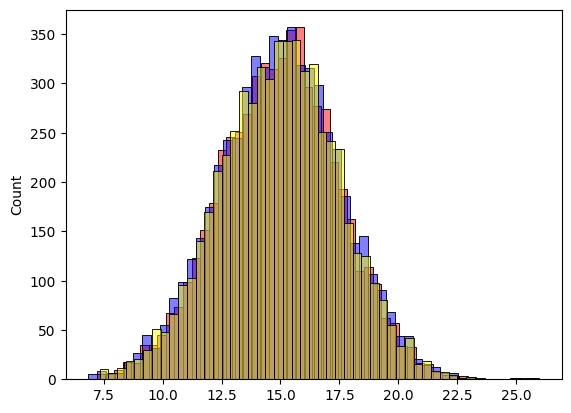

In [28]:
sns.histplot(y_pred_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
sns.histplot(y_pred_mean, color='yellow', alpha=0.5, bins=50)

# Tuning the model

In [29]:
X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    
    # Train on training set
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    # print(f"r={r:<6} w0={w0:.3f}, weights={np.round(w, 3)}")

    # Predict on validation set
    y_pred = w0 + X_val.dot(w)
    
    score = float(rmse(y_val, y_pred))
    print(score, r, w0)



0.5173782638857467 0 28.827365475106156
0.5171115525767522 0.01 24.92683842008767
0.5187525130701821 0.1 11.239661084961272
0.5222348802092772 1 1.7315979411936366
0.5228916092823478 5 0.3638075020692219
0.5229812979636581 10 0.18306246622306527
0.5230636233819926 100 0.018418017306977234


#### Question: If multiple options give the same best RMSE, select the smallest r
##### After rounding RMSE scores to 2 decimal digits, all values were 0.52.
##### Following the instruction to select the smallest r in case of a tie, the best value of r is 0.

# Try different seed values

In [32]:
n = len(df_small)

seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for seed in seed_values:
    np.random.seed(seed)

    # split dataset where 20% is the validation and test data, while 60% is the train data
    n_val = int(0.2 * n) 
    n_test = int(0.2 * n)
    n_train = n - (n_val + n_test)

    # We need to shuffle the dataset before splitting, so we don't have the split in a sequential order
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_shuffled = df_small.iloc[idx]

    # Here we split, we use the copy() so we can still keep the original dataset
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:].copy()

    # We reset the index in a sequential order
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    # The target variables
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values
    

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # .fillna(0) replaces any missing values with 0 (so the math won’t break)
    # .values converts the DataFrame into a NumPy array — because your function train_linear_regression() expects numerical arrays, not Pandas objects.
    X_train = df_train[base].fillna(0).values

    X_val   = df_val[base].fillna(0).values # is this correct
    
    w0, w = train_linear_regression(X_train, y_train)
    

     # Predict on validation set
    y_pred_val = w0 + X_val.dot(w)
    
    score = float(rmse(y_val, y_pred_val))
    scores.append(score)
    print(score, w0)

std_score = np.std(scores)
print("Std (3 d.p.):", round(std_score, 3))
# print("Standard deviation of scores:", std_score)

0.5206531296292951 27.376388747021373
0.5213388912860217 29.022468554558436
0.5228069974785726 25.90435761023051
0.5159516741108942 28.0154500683094
0.5109129460108117 25.93400040593488
0.5283406460133415 25.899506961267985
0.5313910658151165 25.917230934458686
0.5090670387365963 28.41432473071684
0.5147399129426932 26.47841782741041
0.5131865908408015 27.513852582855545
Std (3 d.p.): 0.007


##### Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.